# Sprint 4 - Storytelling e Modelo Preditivo

Fechamento do desafio InsightFlow: consolidacao dos insights das Sprints 1-3
em um storytelling analitico e implementacao de um modelo simples de
regressao linear para previsao do faturamento do proximo mes.


In [1]:
import sys
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve().parent
sys.path.append(str(PROJECT_ROOT / "scripts"))

import eda
import run_sql_queries as sqlq
import modelo_preditivo as mp

conn = sqlite3.connect(eda.DB_PATH)
df = eda.load_vendas(conn)
consultas = sqlq.carregar_consultas()


## 1. A jornada dos dados (Sprint 1 - ETL)

O dataset simulado de e-commerce partiu de **6.120 linhas brutas**, com sujeira
proposital: nulos, duplicados, formatos inconsistentes de data e moeda, e
localidades em formatos variados (`Cidade/UF/Brasil` vs `CIDADE - UF`).

O processo de ETL (`scripts/etl.py`) tratou:
- Duplicados (linhas 100% repetidas e transacoes com `ID_Transacao` repetido).
- Nulos criticos (`ID_Cliente` ausente -> descarte; `Quantidade` ausente ->
  imputacao pela mediana; `Metodo_Pagamento` ausente -> "Nao Informado").
- Padronizacao de datas (3 formatos distintos) e moeda (`R$ 1.234,56` e
  `1234.56`).
- Modelagem relacional em SQLite: tabelas `clientes`, `produtos` e `vendas`.

Resultado: **5.874 linhas tratadas**, prontas para analise.


In [2]:
print(f"Linhas tratadas (vendas): {len(df)}")
print(f"Clientes unicos: {df['ID_Cliente'].nunique()}")
print(f"Produtos unicos: {df['Nome_Produto'].nunique()}")
df.head()


Linhas tratadas (vendas): 5874
Clientes unicos: 1192
Produtos unicos: 25


,ID_Transacao,ID_Cliente,ID_Produto,Data_Venda,Valor_Unitario,Quantidade,Faturamento,Cidade,Estado,Pais,Metodo_Pagamento,Status_Pedido,Nome_Produto,Categoria_Produto
0,TRX002095,CLI01104,PRD0001,2025-07-12,268.33,1,268.33,Recife,PE,Brasil,Pix,Em Processamento,Aspirador de Pó,Casa
1,TRX001427,CLI00020,PRD0001,2025-03-22,30.38,1,30.38,Recife,PE,Brasil,Cartao De Debito,Concluido,Aspirador de Pó,Casa
2,TRX001216,CLI00279,PRD0001,2025-12-15,2875.54,1,2875.54,Fortaleza,CE,Brasil,Cartao De Credito,Concluido,Aspirador de Pó,Casa
3,TRX001739,CLI00079,PRD0001,2025-01-30,1864.12,5,9320.60,Brasília,DF,Brasil,Cartao De Credito,Em Processamento,Aspirador de Pó,Casa
4,TRX003521,CLI00273,PRD0001,2025-04-14,2868.65,4,11474.60,Belo Horizonte,MG,Brasil,Cartao De Credito,Cancelado,Aspirador de Pó,Casa


## 2. Principais achados da EDA e SQL (Sprint 2)

- O ticket medio por venda e de **~R$ 5.339**, com dispersao alta (desvio
  padrao ~R$ 4.134) — mix de produtos de baixo e alto valor.
- `Faturamento` correlaciona com `Valor_Unitario` (0.73) e `Quantidade`
  (0.59), como esperado pela propria formula de calculo; as duas variaveis de
  entrada sao praticamente independentes entre si.
- Apenas **~0,5% dos registros** sao outliers (metodo IQR), concentrados em
  `Faturamento`.
- A receita esta **bem distribuida** entre categorias, estados e clientes: a
  categoria lider (Livros) responde por ~21% do faturamento, e o cliente que
  mais compra responde por menos de 0,3% do total — sem concentracao de
  risco em poucos elementos.
- **Cancelamento + devolucao somam ~40% dos pedidos**, o maior ponto de
  atencao identificado no projeto.
- Uma base RFM (Recencia, Frequencia, Valor) por cliente foi construida via
  SQL e fica pronta para segmentacao.


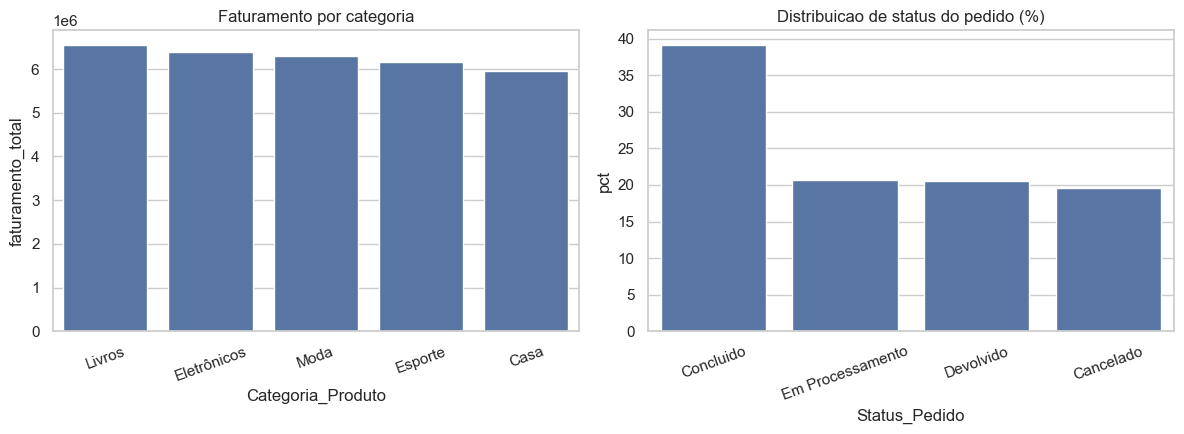

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

faturamento_categoria = pd.read_sql(consultas["faturamento_por_categoria"], conn)
sns.barplot(data=faturamento_categoria, x="Categoria_Produto", y="faturamento_total", ax=axes[0])
axes[0].set_title("Faturamento por categoria")
axes[0].tick_params(axis="x", rotation=20)

status = pd.read_sql(consultas["distribuicao_status_pedido"], conn)
sns.barplot(data=status, x="Status_Pedido", y="pct", ax=axes[1])
axes[1].set_title("Distribuicao de status do pedido (%)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 3. Dashboard e KPIs de negocio (Sprint 3)

O dashboard interativo (`dashboard/app.py`, Streamlit) centraliza os
indicadores para navegacao exploratoria:

- **KPIs**: Faturamento Total, Ticket Medio, Total de Pedidos, Clientes
  Unicos, Churn Rate (% de clientes sem compra ha mais de N dias, limite
  ajustavel) e Taxa de Retencao (clientes que compraram no 1o semestre e
  voltaram no 2o).
- **Serie temporal** de faturamento com granularidade diaria/semanal/mensal
  e media movel, para analise de sazonalidade.
- **Filtros dinamicos**: periodo, categoria, estado, status do pedido e
  metodo de pagamento.

Para rodar: `streamlit run dashboard/app.py`.


## 4. Modelo preditivo (Sprint 4)

Pergunta de negocio: *e possivel prever o faturamento para o proximo mes?*

Abordagem: regressao linear sobre o **faturamento diario agregado**, usando
como features o padrao sazonal (dia da semana, mes, fim de semana). A EDA da
Sprint 2 ja mostrou que o faturamento mensal nao tem uma tendencia de
crescimento clara — por isso o modelo nao usa uma feature de tendencia
linear (dia_ordinal): extrapolar uma reta de tendencia para meses fora do
intervalo de treino distorcia fortemente a previsao.

Split cronologico: os ultimos 30 dias de 2025 ficam como conjunto de teste
(holdout), o restante como treino — nunca embaralhar dados de serie temporal.


In [4]:
diario = mp.carregar_faturamento_diario(conn)
dados = mp.construir_features(diario)
colunas_x = mp.COLUNAS_CATEGORICAS + mp.COLUNAS_NUMERICAS

treino, teste = mp.dividir_treino_teste(dados)
print(f"Treino: {treino['data'].min().date()} a {treino['data'].max().date()} ({len(treino)} dias)")
print(f"Teste:  {teste['data'].min().date()} a {teste['data'].max().date()} ({len(teste)} dias)")

modelo = mp.montar_pipeline()
modelo.fit(treino[colunas_x], treino["faturamento"])
previsao_teste = modelo.predict(teste[colunas_x])

metricas_modelo = mp.avaliar(teste["faturamento"], previsao_teste)
metricas_baseline = mp.avaliar(teste["faturamento"], np.full(len(teste), treino["faturamento"].mean()))

pd.DataFrame([
    {"modelo": "regressao_linear", **metricas_modelo},
    {"modelo": "baseline_media_historica", **metricas_baseline},
])


Treino: 2025-01-01 a 2025-12-01 (335 dias)
Teste:  2025-12-02 a 2025-12-31 (30 dias)


,modelo,mae,rmse,mape,r2
0,regressao_linear,17716.14,21434.05,23.18,-0.023
1,baseline_media_historica,17399.14,21247.63,22.68,-0.006


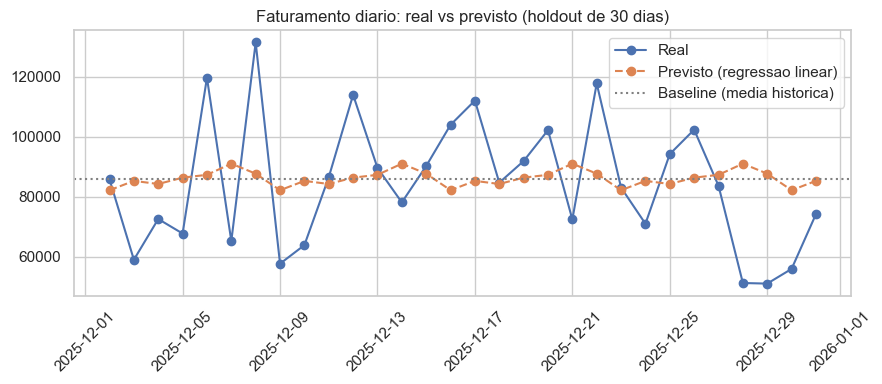

In [5]:
plt.figure(figsize=(9, 4))
plt.plot(teste["data"], teste["faturamento"], marker="o", label="Real")
plt.plot(teste["data"], previsao_teste, marker="o", linestyle="--", label="Previsto (regressao linear)")
plt.axhline(treino["faturamento"].mean(), color="gray", linestyle=":", label="Baseline (media historica)")
plt.xticks(rotation=45)
plt.legend()
plt.title("Faturamento diario: real vs previsto (holdout de 30 dias)")
plt.tight_layout()
plt.show()


**Leitura dos resultados:** o R² fica proximo de zero (levemente negativo) e
o MAE do modelo empata com o do baseline ingenuo (media historica). Isso
significa que **o padrao de dia da semana / mes nao explica a variacao do
faturamento** neste dataset — resultado esperado, ja que os dados foram
gerados de forma aleatoria e uniforme (`scripts/generate_data.py`), sem
sazonalidade real embutida. E um resultado honesto: o modelo nao "inventa"
um padrao que os dados nao tem. Em um cenario com dados reais, o mesmo
pipeline serviria de baseline para incorporar variaveis com sinal real
(campanhas de marketing, feriados, precos, estoque).


In [6]:
modelo_final = mp.montar_pipeline()
modelo_final.fit(dados[colunas_x], dados["faturamento"])
previsao_mensal = mp.prever_periodo_futuro(modelo_final, dados["data"].max(), mp.DIAS_PREVISAO)

faturamento_previsto = previsao_mensal["faturamento_previsto"].sum()
media_mensal_historica = diario.set_index("data")["faturamento"].resample("MS").sum().mean()

print(f"Faturamento previsto para Janeiro/2026: R$ {faturamento_previsto:,.2f}")
print(f"Media mensal historica (2025):          R$ {media_mensal_historica:,.2f}")


Faturamento previsto para Janeiro/2026: R$ 2,552,399.54
Media mensal historica (2025):          R$ 2,613,641.19


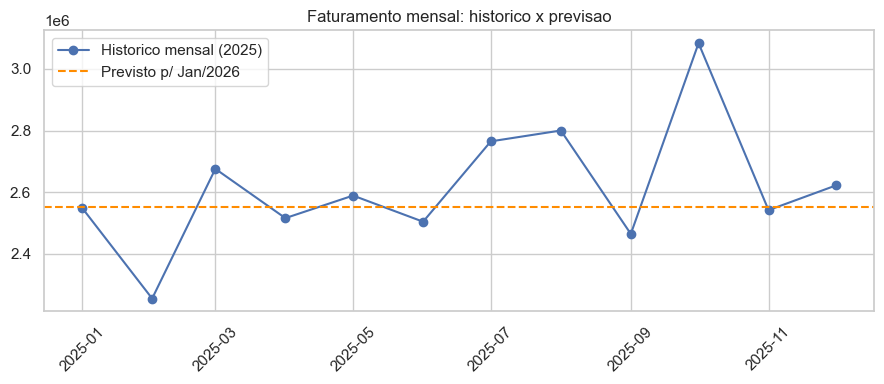

In [7]:
faturamento_mensal_hist = diario.set_index("data")["faturamento"].resample("MS").sum().reset_index()
faturamento_mensal_hist.columns = ["data", "faturamento"]

plt.figure(figsize=(9, 4))
plt.plot(faturamento_mensal_hist["data"], faturamento_mensal_hist["faturamento"], marker="o", label="Historico mensal (2025)")
plt.axhline(faturamento_previsto, color="darkorange", linestyle="--", label="Previsto p/ Jan/2026")
plt.xticks(rotation=45)
plt.legend()
plt.title("Faturamento mensal: historico x previsao")
plt.tight_layout()
plt.show()


## 5. Conclusoes e recomendacoes de negocio

- **Base de dados confiavel**: ETL removeu ~4% das linhas brutas (nulos
  criticos e duplicados) e padronizou 100% dos formatos de data/moeda/texto.
- **Receita saudavel e diversificada**: nenhuma categoria, estado ou cliente
  concentra risco de receita — bom sinal de resiliencia do negocio.
- **Maior oportunidade de melhoria**: ~40% dos pedidos sao cancelados ou
  devolvidos. Recomenda-se investigar causa raiz (checkout, prazos de
  entrega, metodo de pagamento) como proximo passo analitico.
- **Segmentacao pronta**: a base RFM (`sql/consultas_sprint2.sql`) habilita
  campanhas direcionadas por Recencia/Frequencia/Valor.
- **Previsao de faturamento**: com os dados simulados atuais, um modelo de
  regressao linear nao supera uma media historica simples — nao ha
  sazonalidade real para capturar. O pipeline de modelagem (split
  cronologico, baseline de comparacao, metricas MAE/RMSE/MAPE/R²) esta
  pronto para ser reaplicado sobre dados reais, onde variaveis como
  promocoes e feriados devem carregar sinal preditivo de fato.


In [8]:
conn.close()
